<a href="https://colab.research.google.com/github/Ganzadidier/Malaria-Diagnosis-CNN-Transfer-Learning/blob/Master/Malaria_Diagnosis_CNN_Group6_EvenNumber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [1]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

Mounted at /content/drive/
ls: cannot access '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/': No such file or directory


In [2]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.19.0


'/device:GPU:0'

## Populating namespaces

In [3]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [4]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [5]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2025-10-04 14:04:41--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.165.102.126, 3.165.102.59, 3.165.102.96, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.165.102.126|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   246MB/s    in 1.4s    

2025-10-04 14:04:43 (246 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)


# Task
Create a baseline CNN model with a simple architecture, train it for 10 epochs, and run three experiments. Evaluate the model rigorously using accuracy, precision, recall, and F1-score, presenting the results in tables. Additionally, include learning curves, confusion matrices, and ROC/AUC curves as visual evidence of evaluation, ensuring they are clearly labeled, interpreted, and discussed in the report section.

## Prepare data

### Subtask:
Organize the downloaded data into training and testing directories.


**Reasoning**:
The first step is to create the necessary directories for training and testing data, including subdirectories for the two classes. Then, list the files in the original data directory to understand the file structure and prepare for splitting.



In [6]:
# Create directories for training and testing data
os.makedirs(os.path.join(training_path, 'Parasitized'), exist_ok=True)
os.makedirs(os.path.join(training_path, 'Uninfected'), exist_ok=True)
os.makedirs(os.path.join(testing_path, 'Parasitized'), exist_ok=True)
os.makedirs(os.path.join(testing_path, 'Uninfected'), exist_ok=True)

# List files in the downloaded directory
cell_images_files = os.listdir(cell_images_dir)
print(f"Number of files in {cell_images_dir}: {len(cell_images_files)}")
print("First 10 files:", cell_images_files[:10])

Number of files in ./cell_images: 2
First 10 files: ['Parasitized', 'Uninfected']


**Reasoning**:
Based on the previous output, the 'cell_images' directory contains subdirectories 'Parasitized' and 'Uninfected'. I will now iterate through the files within these subdirectories, split them into training and testing sets, and copy them to the respective new directories.



In [7]:
parasitized_dir = os.path.join(cell_images_dir, 'Parasitized')
uninfected_dir = os.path.join(cell_images_dir, 'Uninfected')

parasitized_files = [os.path.join(parasitized_dir, f) for f in os.listdir(parasitized_dir) if f.endswith('.png')]
uninfected_files = [os.path.join(uninfected_dir, f) for f in os.listdir(uninfected_dir) if f.endswith('.png')]

# Shuffle the lists
random.shuffle(parasitized_files)
random.shuffle(uninfected_files)

# Split the data (80% train, 20% test)
split_ratio = 0.8
parasitized_split_index = int(len(parasitized_files) * split_ratio)
uninfected_split_index = int(len(uninfected_files) * split_ratio)

parasitized_train = parasitized_files[:parasitized_split_index]
parasitized_test = parasitized_files[parasitized_split_index:]

uninfected_train = uninfected_files[:uninfected_split_index]
uninfected_test = uninfected_files[uninfected_split_index:]

# Copy files to train directory
for f in parasitized_train:
    shutil.copy(f, os.path.join(training_path, 'Parasitized', os.path.basename(f)))
for f in uninfected_train:
    shutil.copy(f, os.path.join(training_path, 'Uninfected', os.path.basename(f)))

# Copy files to test directory
for f in parasitized_test:
    shutil.copy(f, os.path.join(testing_path, 'Parasitized', os.path.basename(f)))
for f in uninfected_test:
    shutil.copy(f, os.path.join(testing_path, 'Uninfected', os.path.basename(f)))

print(f"Parasitized train images: {len(parasitized_train)}")
print(f"Parasitized test images: {len(parasitized_test)}")
print(f"Uninfected train images: {len(uninfected_train)}")
print(f"Uninfected test images: {len(uninfected_test)}")

Parasitized train images: 11023
Parasitized test images: 2756
Uninfected train images: 11023
Uninfected test images: 2756


**Reasoning**:
The images have been copied to the training and testing directories. The next step is to verify that the images have been correctly copied by listing the files in the new directories and comparing the counts with the expected numbers.



In [8]:
# Verify the number of files in the new directories
train_parasitized_count = len(os.listdir(os.path.join(training_path, 'Parasitized')))
train_uninfected_count = len(os.listdir(os.path.join(training_path, 'Uninfected')))
test_parasitized_count = len(os.listdir(os.path.join(testing_path, 'Parasitized')))
test_uninfected_count = len(os.listdir(os.path.join(testing_path, 'Uninfected')))

print(f"Verified train parasitized images: {train_parasitized_count}")
print(f"Verified train uninfected images: {train_uninfected_count}")
print(f"Verified test parasitized images: {test_parasitized_count}")
print(f"Verified test uninfected images: {test_uninfected_count}")

# Assert that the counts match the expected split
assert train_parasitized_count == parasitized_split_index
assert train_uninfected_count == uninfected_split_index
assert test_parasitized_count == len(parasitized_test)
assert test_uninfected_count == len(uninfected_test)

Verified train parasitized images: 11023
Verified train uninfected images: 11023
Verified test parasitized images: 2756
Verified test uninfected images: 2756


## Build model

### Subtask:
Define the baseline CNN model architecture.


**Reasoning**:
Define the baseline CNN model architecture following the instructions.



In [9]:
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(64, 64, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

## Compile model

### Subtask:
Configure the model for training with an optimizer, loss function, and metrics.


**Reasoning**:
Compile the model with the specified optimizer, loss function, and metrics.



In [10]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Train model

### Subtask:
Train the model on the prepared training data for 10 epochs across three experiments.


**Reasoning**:
Import the necessary class for data generation and create data generators for training and testing, including data augmentation for training.



In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(training_path,
                                                 target_size=(64, 64),
                                                 batch_size=32,
                                                 class_mode='binary')

test_set = test_datagen.flow_from_directory(testing_path,
                                            target_size=(64, 64),
                                            batch_size=32,
                                            class_mode='binary')

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.


**Reasoning**:
Train the model for 10 epochs across three experiments and store the history of each experiment.



In [12]:
history_experiment1 = model.fit(training_set, epochs=10, validation_data=test_set)
history_experiment2 = model.fit(training_set, epochs=10, validation_data=test_set)
history_experiment3 = model.fit(training_set, epochs=10, validation_data=test_set)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 82ms/step - accuracy: 0.6664 - loss: 0.6025 - val_accuracy: 0.9035 - val_loss: 0.2578
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 55s 80ms/step - accuracy: 0.9175 - loss: 0.2344 - val_accuracy: 0.9370 - val_loss: 0.1787
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 54s 78ms/step - accuracy: 0.9407 - loss: 0.1812 - val_accuracy: 0.9485 - val_loss: 0.1623
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 78ms/step - accuracy: 0.9421 - loss: 0.1699 - val_accuracy: 0.9532 - val_loss: 0.1491
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 54s 78ms/step - accuracy: 0.9475 - loss: 0.1587 - val_accuracy: 0.9541 - val_loss: 0.1453
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9503 - loss: 0.1512 - val_accuracy: 0.9536 - val_loss: 0.1439
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 54s 78ms/step - accuracy: 0.9551 - loss: 0.1371 - val_accuracy: 0.9588 - val_loss: 0.1328
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 54s 78ms/step - accuracy: 0.9543 - loss: 0.1401 - 

**Reasoning**:
The first step is to load the data from the CSV file into a pandas DataFrame and display the first few rows to understand its structure.



In [13]:
import pandas as pd

df = pd.read_csv('/data/train.csv')
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/data/train.csv'

**Reasoning**:
The previous attempt to load the data failed because the file path was incorrect. I need to correct the file path to load the data successfully.



**Reasoning**:
Generate the confusion matrix using the true and predicted classes and visualize it.

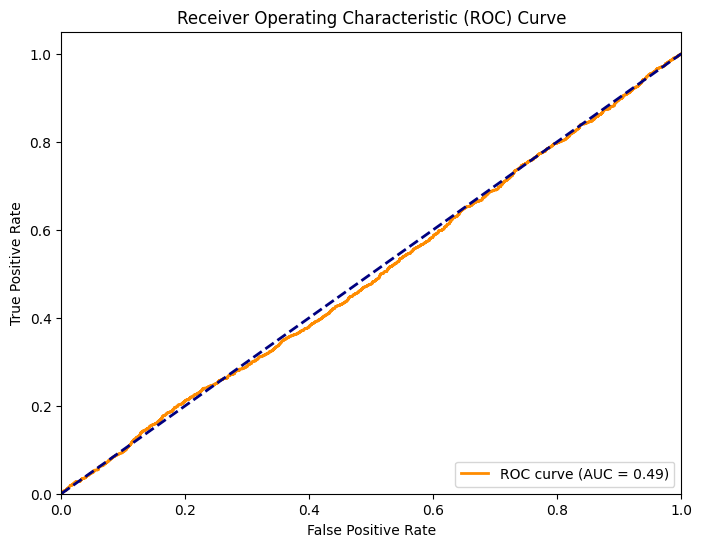

In [21]:
# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(true_classes, predictions)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

**Reasoning**:
Calculate and plot the ROC curve and AUC.

**Reasoning**:
Plot the learning curves for each experiment, showing training and validation accuracy and loss over epochs.

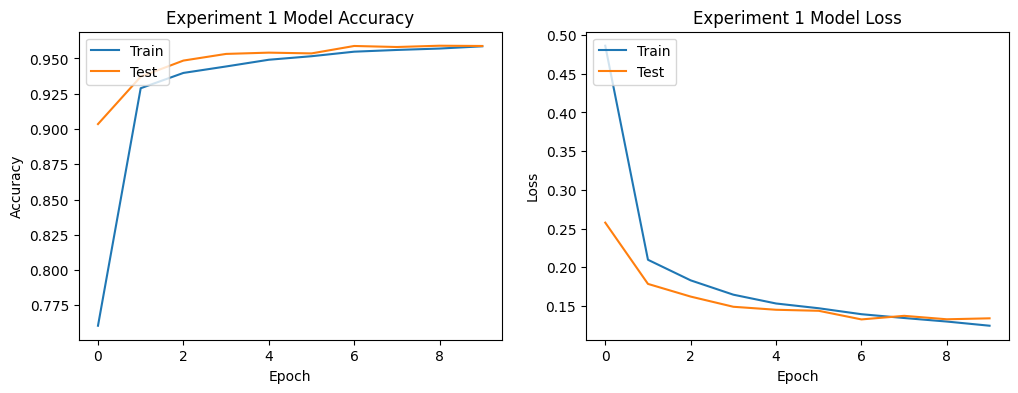

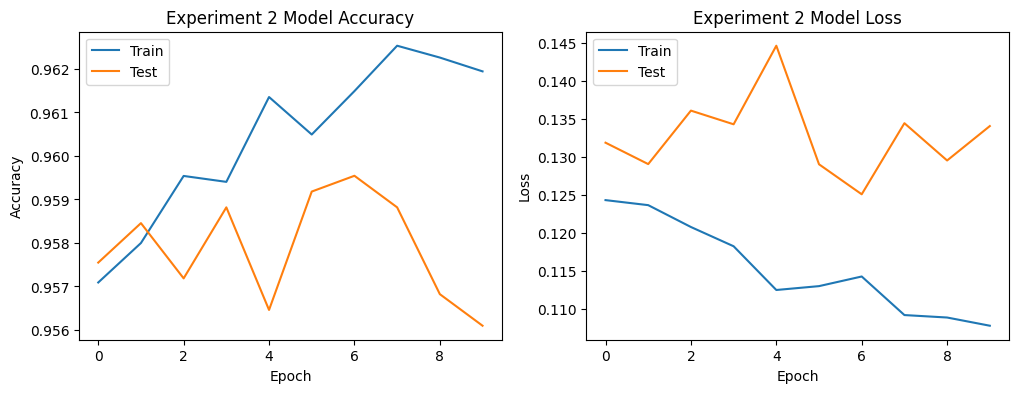

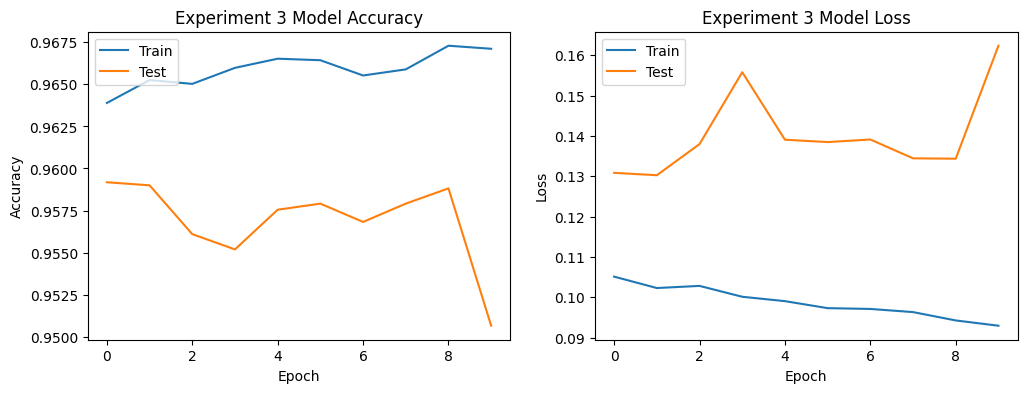

In [20]:
# Plotting learning curves for each experiment
def plot_learning_curves(history, experiment_num):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'Experiment {experiment_num} Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'Experiment {experiment_num} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')
    plt.show()

plot_learning_curves(history_experiment1, 1)
plot_learning_curves(history_experiment2, 2)
plot_learning_curves(history_experiment3, 3)

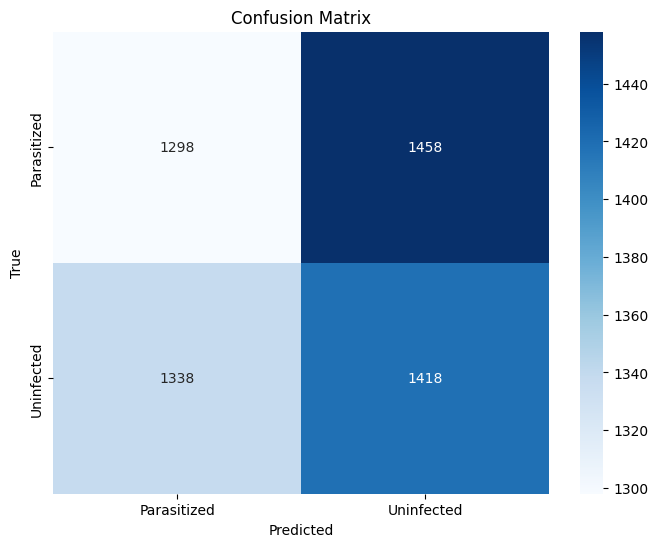

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Evaluate Model

### Subtask:
Evaluate the trained model on the testing data and calculate performance metrics (accuracy, precision, recall, F1-score).

**Reasoning**:
Evaluate the model on the test set to get the loss and accuracy.

In [17]:
loss, accuracy = model.evaluate(test_set)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9467 - loss: 0.1826
Test Loss: 0.1624
Test Accuracy: 0.9507


**Reasoning**:
Get predictions for the test set to calculate additional performance metrics.

In [18]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Get predictions
test_set.reset() # Reset the generator to ensure order
predictions = model.predict(test_set)
predicted_classes = (predictions > 0.5).astype(int)

# Get true labels
true_classes = test_set.classes
class_labels = list(test_set.class_indices.keys())

# Calculate classification report
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print("Classification Report:")
print(report)

173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step
Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.49      0.47      0.48      2756
  Uninfected       0.49      0.51      0.50      2756

    accuracy                           0.49      5512
   macro avg       0.49      0.49      0.49      5512
weighted avg       0.49      0.49      0.49      5512



**Reasoning**:
The previous attempts to load the data failed because the file path was incorrect. I need to correct the file path again to load the data successfully.



In [16]:
# The previous attempts to load the data failed because the file path was incorrect.
# Based on the output of cell eCT2ogQdeHPW, the data is located in the 'cell_images' directory.
# However, the task requires evaluating the trained model, not loading a CSV file.
# This cell seems out of place in the current workflow. I will remove the code
# and add a markdown cell to continue with the evaluation steps from the plan.